In [46]:
# Import Library
import sys
import pandas as pd
import numpy as np
import plotly.express as px
import plotly as py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

from collections import Counter
from PIL import Image

import pandas as pd
from pathlib import Path

import calendar
!pip install termcolor
from termcolor import colored
from IPython.display import HTML

import warnings
warnings.filterwarnings("ignore")
py.offline.init_notebook_mode(connected = True)

### Problem statement- Patient risk segmentation
### We have given Patient health data
### Task (1) Handle missing values (2) Decide whether to use risk_score or not (justify) (3) Scale the data (4) Apply K-means clustering, (5) Determine optimal K, (6) Interpret clusters 
### Expected Business Interpretation: (1) Healthy Patient (2) Moderate risk patients (3) High-risk patients (4) Critical patients 
### Questions to Answer, (1) Does including risk_score improve clustering? (2)	Which features contribute most to high-risk clusters? 
###	(3) Are there younger patients with high risk?

In [27]:
df1 = pd.read_csv(r"D:\GenAI\IIT M Pravartak\Content\Assignment\4. 19-Apr-26_K_Means\healthcare.csv")

In [28]:
df1.head()

,age,bp,cholesterol,glucose,risk_score
0,55.0,148.320412,188.612861,139.835269,15.701409
1,22.0,117.930592,179.367809,82.123981,12.203911
2,52.0,147.973495,234.216707,177.079308,18.548878
3,34.0,173.554020,311.106689,149.875777,20.534852
4,35.0,105.344423,172.862767,84.217231,11.714905


In [29]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          246 non-null    float64
 1   bp           246 non-null    float64
 2   cholesterol  246 non-null    float64
 3   glucose      246 non-null    float64
 4   risk_score   246 non-null    float64
dtypes: float64(5)
memory usage: 10.2 KB


In [30]:
df1.isna().sum()

age            12
bp             12
cholesterol    12
glucose        12
risk_score     12
dtype: int64

In [31]:
# Apply filter to see the observations with missing data
df1[df1.isna().any(axis=1)]

,age,bp,cholesterol,glucose,risk_score
8,43.0,105.932793,161.992550,83.241953,NaN
12,NaN,150.823789,212.098409,134.857555,NaN
13,43.0,NaN,226.806771,97.778238,14.383971
18,NaN,121.027637,252.590189,106.906416,15.484791
25,44.0,132.693177,NaN,105.692899,14.815065
29,NaN,143.895836,313.668693,137.026072,19.207979
31,46.0,NaN,302.753545,118.849375,17.610547
33,38.0,131.862123,250.679112,136.710942,NaN
40,55.0,NaN,195.491856,185.569575,17.812359
47,NaN,125.051066,NaN,137.704705,14.738805


<Axes: >

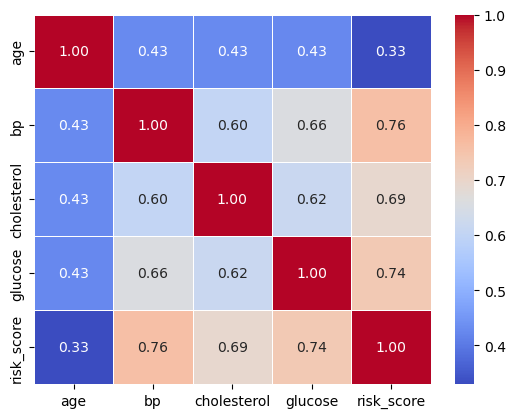

In [32]:
# Checking for correlation among features
# Calculate the correlation matrix
corr_matrix = df1.corr()

# Create and display the heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [33]:
# Risk score and glucose have a correlation of 0.74
# Risk score and BP have a correlation of 0.76
# Risk score is strongly correlated with both Glucose and BP

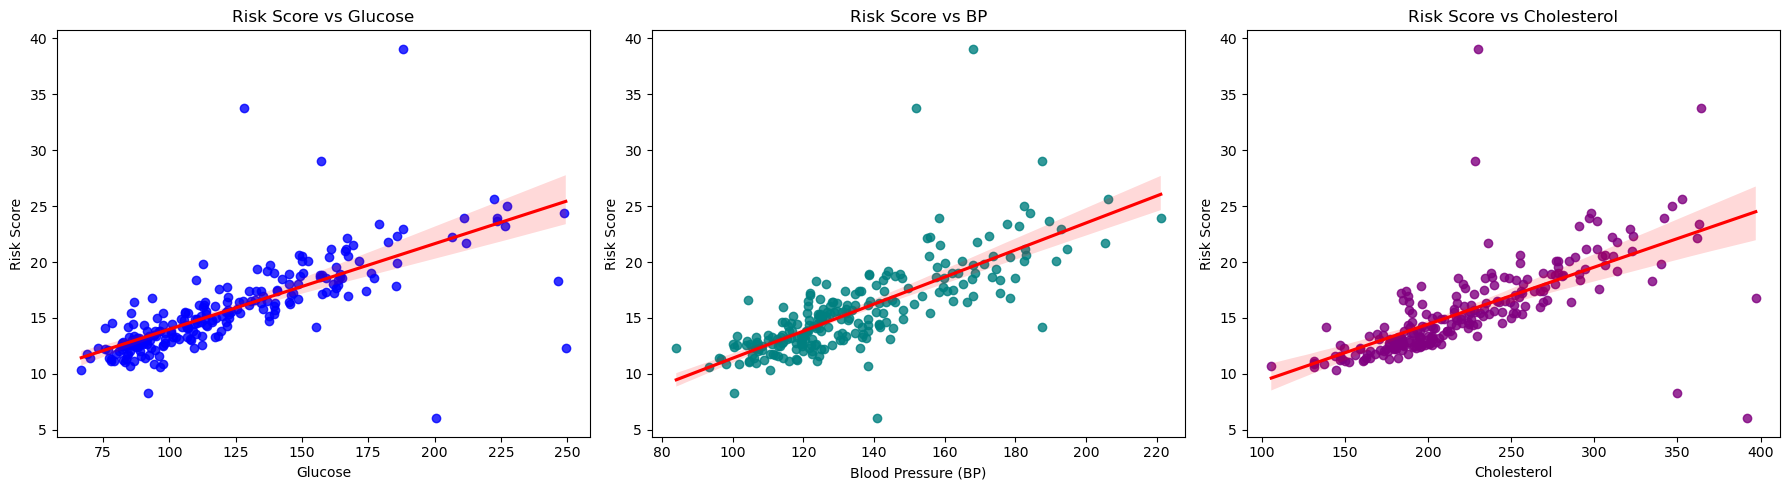

In [34]:
# Plotting scatter plot to see if there is any linear relattionship 
# Set up a 1 row by 3 columns layout for side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter plot between Risk Score and Glucose
sns.regplot(data=df1, x='glucose', y='risk_score', ax=axes[0], color='blue', line_kws={'color':'red'})
axes[0].set_title('Risk Score vs Glucose')
axes[0].set_xlabel('Glucose')
axes[0].set_ylabel('Risk Score')

# 2. Scatter plot between Risk Score and Blood Pressure (BP)
sns.regplot(data=df1, x='bp', y='risk_score', ax=axes[1], color='teal', line_kws={'color':'red'})
axes[1].set_title('Risk Score vs BP')
axes[1].set_xlabel('Blood Pressure (BP)')
axes[1].set_ylabel('Risk Score')

# 3. Scatter plot between Risk Score and Cholesterol
sns.regplot(data=df1, x='cholesterol', y='risk_score', ax=axes[2], color='purple', line_kws={'color':'red'})
axes[2].set_title('Risk Score vs Cholesterol')
axes[2].set_xlabel('Cholesterol')
axes[2].set_ylabel('Risk Score')

# Automatically adjust spacing between plots to prevent overlap
plt.tight_layout()

In [35]:
# Here is my approach
# 1 Missing value imputation 
# 2 Data centering around mean and scaling
# 3 Drop "risk score" as it is strongly co-related with Glucose and BP
# 4 Calculate Principal components since feature BP is moderately co-related with Glucose and Cholestrol
# 5 Calculate clusters using K Means

In [36]:
# Step 1 - Missing value imputation
from sklearn.experimental import enable_iterative_imputer  # Explicitly required to use IterativeImputer
from sklearn.impute import IterativeImputer
import pandas as pd

# 1. Isolate the columns you want to use for the cross-variable imputation
# We include age to give the model more context, but exclude risk_score to avoid leakage
impute_cols = ['age', 'bp', 'cholesterol', 'glucose']

# 2. Initialize the Iterative Imputer
# random_state ensures your results are reproducible every time you run it
imputer = IterativeImputer(max_iter=10, random_state=42)

# 3. Create a copy of the dataframe and fit/transform the columns
df_imputed = df1.copy()
df_imputed[impute_cols] = imputer.fit_transform(df_imputed[impute_cols])

# 4. Check if any missing values remain in those columns
print(df_imputed[impute_cols].isna().sum())

age            0
bp             0
cholesterol    0
glucose        0
dtype: int64


In [37]:
df_imputed.head()

,age,bp,cholesterol,glucose,risk_score
0,55.0,148.320412,188.612861,139.835269,15.701409
1,22.0,117.930592,179.367809,82.123981,12.203911
2,52.0,147.973495,234.216707,177.079308,18.548878
3,34.0,173.554020,311.106689,149.875777,20.534852
4,35.0,105.344423,172.862767,84.217231,11.714905


In [38]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Start with your base dataframe and isolate target columns
df_custom = df1.copy()
features = ['age', 'bp', 'cholesterol', 'glucose']

# 2. Initial Imputation: Fill NaNs temporarily with the median
# Models cannot train if independent variables contain NaNs
for col in features:
    median_val = df_custom[col].median()
    # Track where the original missing values were
    df_custom[f'{col}_was_missing'] = df_custom[col].isna()
    df_custom[col] = df_custom[col].fillna(median_val)

# 3. The Iterative Loop (Chained Equations)
max_iter = 3  # Number of times to cycle through all columns

for iteration in range(max_iter):
    for target_col in ['bp', 'cholesterol', 'glucose']:
        
        # Predictors are all features EXCEPT the current target column
        predictor_cols = [c for c in features if c != target_col]
        
        # Identify rows where the target column was originally missing
        missing_mask = df_custom[f'{target_col}_was_missing']
        
        # Split data into training (originally had data) and prediction sets
        X_train = df_custom.loc[~missing_mask, predictor_cols]
        y_train = df_custom.loc[~missing_mask, target_col]
        X_missing = df_custom.loc[missing_mask, predictor_cols]
        
        if len(X_missing) > 0:
            # Train a linear model on the known data points
            model = LinearRegression()
            model.fit(X_train, y_train)
            
            # Predict values for the missing rows using the other updated columns
            predictions = model.predict(X_missing)
            
            # Update only the missing slots with our new predictions
            df_custom.loc[missing_mask, target_col] = predictions

# Clean up our tracker columns
df_custom = df_custom.drop(columns=[f'{c}_was_missing' for c in features])

In [39]:
df_custom.isna().sum()

age             0
bp              0
cholesterol     0
glucose         0
risk_score     12
dtype: int64

In [42]:
# Step 2: Drop "risk score" as it is strongly co-related with Glucose and BP
df_imputed.drop(['risk_score'], axis = 1, inplace = True)

In [43]:
df_imputed.head()

,age,bp,cholesterol,glucose
0,55.0,148.320412,188.612861,139.835269
1,22.0,117.930592,179.367809,82.123981
2,52.0,147.973495,234.216707,177.079308
3,34.0,173.554020,311.106689,149.875777
4,35.0,105.344423,172.862767,84.217231


In [44]:
# Step 3: Standardization and centering the data
scaler = StandardScaler()
X = scaler.fit_transform(df_imputed)

In [48]:
# Step 4 Calculate Principal components since feature BP is moderately co-related with Glucose and Cholestrol
# Apply PCA
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

In [49]:
## HOW MUCH INFORMATION DID WE RETAIN?
print(pca.explained_variance_ratio_)
print("Total variance captured:", sum(pca.explained_variance_ratio_))

[0.65732904 0.15977638 0.10024986 0.08264472]
Total variance captured: 1.0


In [52]:
# Visualise composition of PCA
features = ['age', 'bp', 'cholesterol', 'glucose']
loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=['PC1', 'PC2', 'PC3', 'PC4']
)

print(loadings)

          age        bp  cholesterol   glucose
PC1  0.425976  0.523421     0.514419  0.529101
PC2  0.904178 -0.262630    -0.213329 -0.260728
PC3 -0.031629 -0.510576     0.817581 -0.264336
PC4  0.002620 -0.629578    -0.146372  0.763020


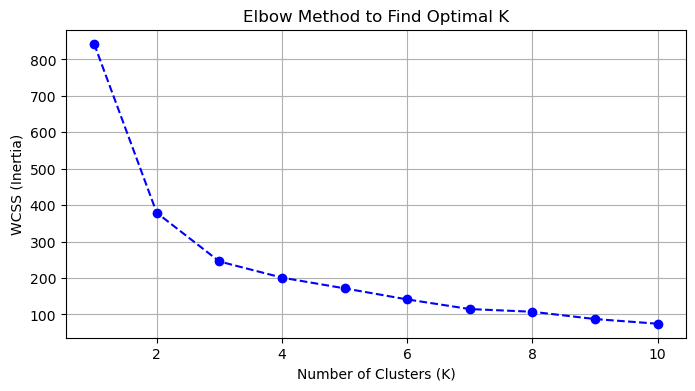


--- Average Health Metrics per Cluster ---
               age          bp  cholesterol     glucose
Cluster                                                
0        55.567143  130.645241   222.703808  118.103310
1        63.637463  180.312675   317.009891  198.170465
2        36.460839  116.721524   182.786356   93.218056
3        53.666524  159.311243   266.035608  153.214265


In [53]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Slice your PCA data to keep only the first 2 principal components
# This captures ~81.7% of the variance and makes visualization easy
X_pca_2d = X_pca[:, :2]

# 2. Determine optimal K using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans_test = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_test.fit(X_pca_2d)
    wcss.append(kmeans_test.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# 3. Fit K-Means using your target number of clusters 
optimal_k = 4 
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_pca_2d)

# 4. Map the clusters back to your original DataFrame for interpretation
df_2['Cluster'] = cluster_labels

# Let's see the average health metrics for each cluster to identify risk segments
cluster_summary = df_2.groupby('Cluster').mean()
print(colored("\n--- Average Health Metrics per Cluster ---", "blue", attrs=["bold"]))
print(cluster_summary)

In [56]:
# Cluster 0: Moderate Risk Patients. Profile: Middle-aged group (Average Age: ~55 years) High cholestrol
# CLuster 1: Critical patients. Profile: Older individuals (Average Age: ~62 years), very high cholestrol and glucose level
# Cluster 2: Healthy patients. Profile: Youngest individuals. Avg. age 36 years, BP, Cholestrol and Glucose is optimal
# Cluster 3: High risk patients. Profile: Middle-aged group (Average Age: ~53 years), BP elevated, Cholestrol, highly elevated and high Glucose

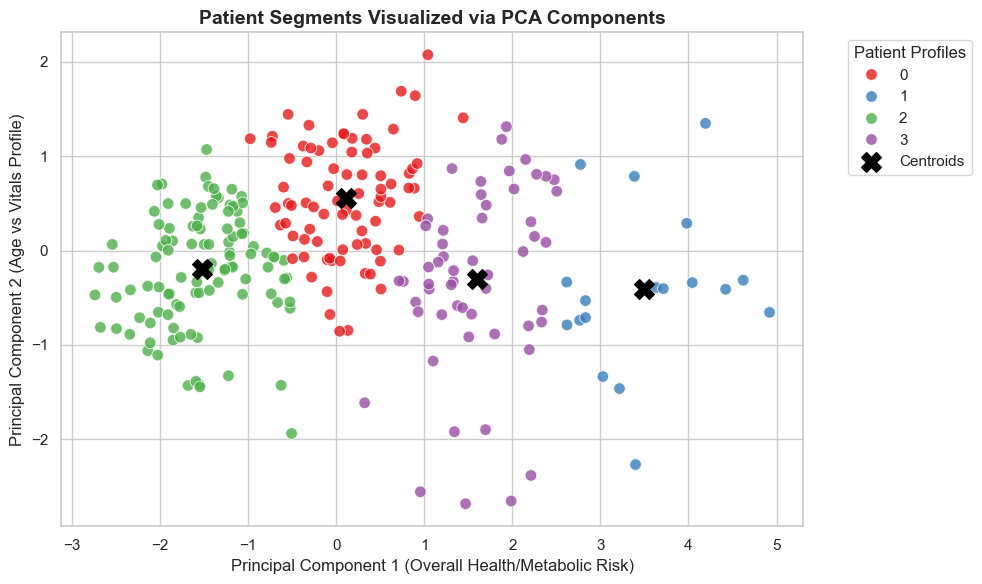

In [54]:
# Print cluster

# Set up the plotting style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create a scatter plot of the two Principal Components, colored by Cluster
scatter = sns.scatterplot(
    x=X_pca_2d[:, 0], 
    y=X_pca_2d[:, 1], 
    hue=df_2['Cluster'], 
    palette='Set1', 
    s=70, 
    alpha=0.8
)

# Plot the cluster centers (centroids)
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    marker='X', 
    s=200, 
    color='black', 
    label='Centroids'
)

# Add titles and labels
plt.title('Patient Segments Visualized via PCA Components', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (Overall Health/Metabolic Risk)', fontsize=12)
plt.ylabel('Principal Component 2 (Age vs Vitals Profile)', fontsize=12)
plt.legend(title='Patient Profiles', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [55]:
# Filter for patients younger than 40 who landed in the High-Risk or Critical clusters
young_high_risk = df_2[(df_2['age'] < 40) & (df_2['Cluster'].isin([1, 3]))]
print(f"Found {len(young_high_risk)} young patients at high/critical risk:")
print(young_high_risk)

Found 7 young patients at high/critical risk:
      age          bp  cholesterol     glucose  Cluster
3    34.0  173.554020   311.106689  149.875777        3
168  30.0  168.078802   216.951953  135.433189        3
233  31.0  172.440196   322.959004  185.896643        3
253  31.0  151.773516   364.218484  128.142016        3
255  26.0  123.643175   334.932583  246.360842        3
256  22.0  167.916228   229.916708  188.104123        3
257  22.0  178.445301   397.103997   93.368761        3
